# Basic imports

In [ ]:
# Scaling check for || C12 C22^{-1} Xi21 ||_op
#
# Model:
#   - Haar-isometry rank-one POVM: mu_a = V_a^\dagger V_a, sum_a mu_a = I_d
#   - Haar-random pure training states rho_i = |psi_i><psi_i|
#   - Exact probabilities P_{ai} = Tr(mu_a rho_i) = |(V psi_i)_a|^2
#   - Block bases U1,U2,V1 are obtained from the SVD of P
#   - C_ab = (1/p) sum_i (Pi2)_{ii} U_a^T Sigma_i U_b
#   - Xi21 = U2^T Xi V1
#   - term = C12 C22^{-1} Xi21

import numpy as np
import matplotlib.pyplot as plt

from qelm import (
    QELMDataSpec,
    QELMNoiseSpec,
    QELMTargetRequest,
    QELMTestRequest,
    QELMTrainingSpec,
    QELMRun,
    TildeUTrainingApproxStudySpec,
    generate_random_rank1_povm,
    plot_summary_series, plot_saved_traindata,
    run_tilde_u_training_approx_report,
    run_schur_complement_approx_experiment,
    run_schur_correction_report,
)
from qelm.plotting import plot_mse_grid_over_N

SCHUR_COMPLEMENT_APPROX_PLOTS = [
    {
        "title": "Schur-complement relative approximation error",
        "ylabel": "relative operator-norm error",
        "threshold": "relative_error",
        "series": [
            ("limit_relative_error", "error: Xi11 - C12 C22^+ Xi21"),
            ("xi11_relative_error", "error: Xi11 only"),
        ],
    },
    {
        "title": "Schur-complement absolute approximation error",
        "ylabel": "absolute operator-norm error",
        "series": [
            ("limit_approx_error_op", "||Schur - (Xi11 - C12 C22^+ Xi21)||"),
            ("xi11_approx_error_op", "||Schur - Xi11||"),
        ],
    },
    {
        "title": "When the Xi11-only approximation is plausible",
        "ylabel": "correction size relative to Xi11",
        "series": [
            ("empirical_correction_over_xi11", "||S12 S22^+ Xi21|| / ||Xi11||"),
            ("limit_correction_over_xi11", "||C12 C22^+ Xi21|| / ||Xi11||"),
        ],
    },
]

SCHUR_COMPLEMENT_NORM_PLOTS = [
    {
        "title": "Operator norms of Schur-complement pieces",
        "ylabel": "operator norm",
        "series": [
            ("empirical_schur_op", "||Xi11 - S12 S22^+ Xi21||"),
            ("xi11_op", "||Xi11||"),
            ("limit_approx_op", "||Xi11 - C12 C22^+ Xi21||"),
        ],
    },
]

mub_povm = np.array([
    [[1, 0], [0, 0]],  # |0><0|
    [[0, 0], [0, 1]],  # |1><1|
    [[0.5, 0.5], [0.5, 0.5]],  # |+><+|
    [[0.5, -0.5], [-0.5, 0.5]],  # |-><-|
    [[0.5, -0.5j], [0.5j, 0.5]],  # |+i><+i|
    [[0.5, 0.5j], [-0.5j, 0.5]]  # |-i><-i|
]) / 3


/home/lucainnocenti/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Schur stuff experiments

nout=    8, ntr=   800, trials=3
nout=   12, ntr=  1200, trials=3
nout=   16, ntr=  1600, trials=3
nout=   24, ntr=  2400, trials=3
nout=   32, ntr=  3200, trials=3
nout=   48, ntr=  4800, trials=3
nout=   64, ntr=  6400, trials=3


,d,r,nout,ntr,q,p_kernel,Nshots,noise,trials,term_op_mean,...,term_fro_median,C12_op_median,Xi21_op_median,Gamma_op_median,Gamma_trace_median,C22_lambda_min_median,C22_cond_median,C22_kept_rank_min,P_numerical_rank_min,q_over_p
0,2,4,8,800,4,796,10000,gaussian,3,0.340268,...,0.315073,0.036621,0.921930,0.021174,0.039228,0.017396,9.847820,4,4,0.005025
1,2,4,12,1200,8,1196,10000,gaussian,3,0.386796,...,0.471589,0.047983,0.949319,0.036175,0.060777,0.017882,7.348309,8,4,0.006689
2,2,4,16,1600,12,1596,10000,gaussian,3,0.337476,...,0.438750,0.040315,1.080021,0.020795,0.042510,0.007610,14.671606,12,4,0.007519
3,2,4,24,2400,20,2396,10000,gaussian,3,0.369474,...,0.458432,0.035065,0.966917,0.022226,0.045923,0.005503,16.780464,20,4,0.008347
4,2,4,32,3200,28,3196,10000,gaussian,3,0.412401,...,0.516814,0.029735,1.248572,0.020381,0.038410,0.006766,9.961707,28,4,0.008761
5,2,4,48,4800,44,4796,10000,gaussian,3,0.352407,...,0.388625,0.030141,1.096149,0.022525,0.034188,0.001940,27.048407,44,4,0.009174
6,2,4,64,6400,60,6396,10000,gaussian,3,0.218758,...,0.275261,0.014260,1.102327,0.007871,0.023547,0.001783,26.128625,60,4,0.009381


,x,y,slope,intercept,law
0,q,term_op_median,-0.062515,-0.922189,term_op_median ~ q^-0.063
1,q,Gamma_trace_median,-0.201810,-2.656272,Gamma_trace_median ~ q^-0.202
2,q,Gamma_op_median,-0.285146,-3.091003,Gamma_op_median ~ q^-0.285
3,q,C12_op_median,-0.302512,-2.582216,C12_op_median ~ q^-0.303
4,q,C22_lambda_min_median,-0.904260,-2.499879,C22_lambda_min_median ~ q^-0.904


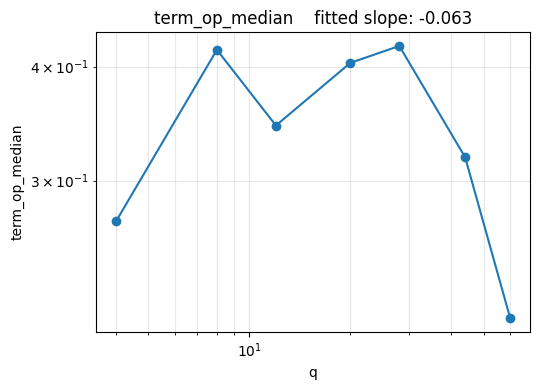

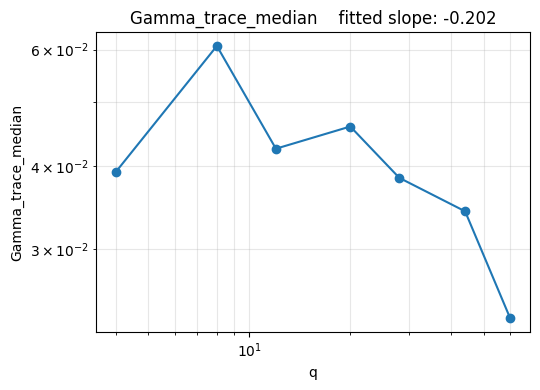

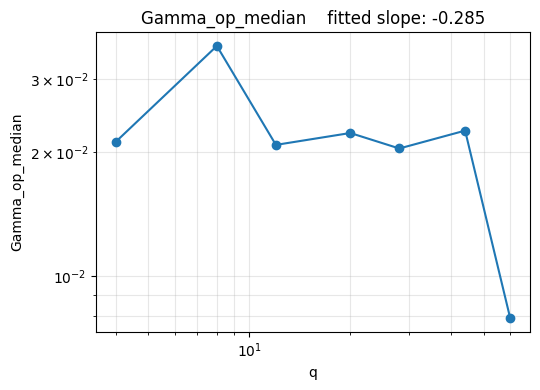

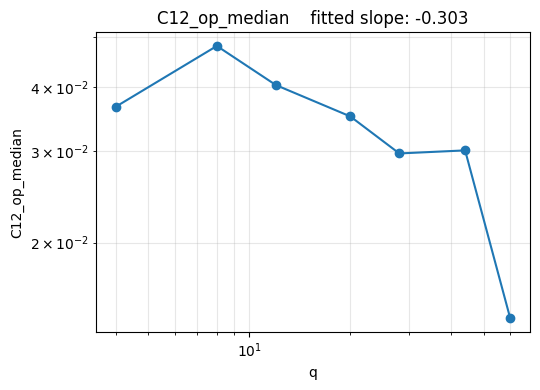

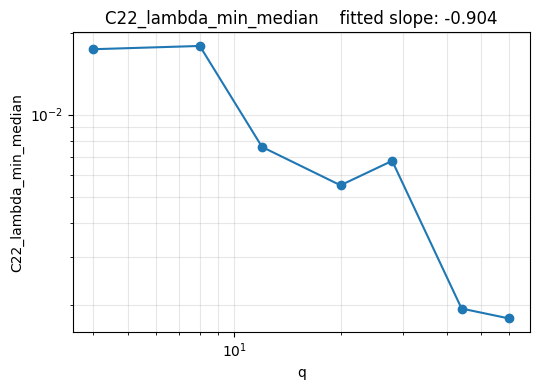

In [2]:
# ---------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------
#
# 1. Scaling with nout, with ntr proportional to nout:

raw, summary, slopes = run_schur_correction_report(
    sweep_col="nout",
    d=2,
    nout_values=(8, 12, 16, 24, 32, 48, 64),
    ntr_multiplier=100,
    trials=3,
    noise="gaussian",      # large-shot limit; fastest
    seed=7,
    rcond=1e-12,
)


nout=   32, ntr=   128, trials=30
nout=   32, ntr=   256, trials=30
nout=   32, ntr=   512, trials=30
nout=   32, ntr=  1024, trials=30
nout=   32, ntr=  2048, trials=30
nout=   32, ntr=  4096, trials=30


/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
/tmp/ipykernel_3491540/177977974.py:94: RankWarning: Polyfit may be poorly conditioned
  slope, intercept = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)


,d,r,nout,ntr,q,p_kernel,Nshots,noise,trials,term_op_mean,...,term_fro_median,C12_op_median,Xi21_op_median,Gamma_op_median,Gamma_trace_median,C22_lambda_min_median,C22_cond_median,C22_kept_rank_min,P_numerical_rank_min,q_over_p
0,2,4,32,128,28,124,10000,gaussian,30,0.323249,...,0.404252,0.024791,1.136514,0.014419,0.035402,0.003906,18.509395,28,4,0.225806
1,2,4,32,256,28,252,10000,gaussian,30,0.280112,...,0.336990,0.023620,1.081721,0.013315,0.032607,0.003815,18.308548,28,4,0.111111
2,2,4,32,512,28,508,10000,gaussian,30,0.302547,...,0.363085,0.024918,1.146141,0.015586,0.032642,0.003510,19.881164,28,4,0.055118
3,2,4,32,1024,28,1020,10000,gaussian,30,0.284083,...,0.337390,0.023457,1.125003,0.013839,0.032788,0.003578,18.086878,28,4,0.027451
4,2,4,32,2048,28,2044,10000,gaussian,30,0.331646,...,0.391012,0.023617,1.142062,0.014204,0.035478,0.003575,19.286162,28,4,0.013699
5,2,4,32,4096,28,4092,10000,gaussian,30,0.320779,...,0.355831,0.026554,1.100760,0.017417,0.039810,0.003715,19.530025,28,4,0.006843


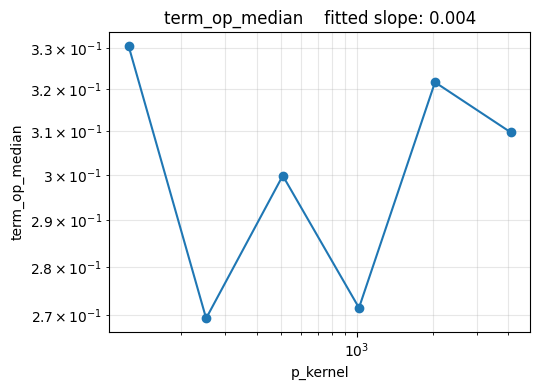

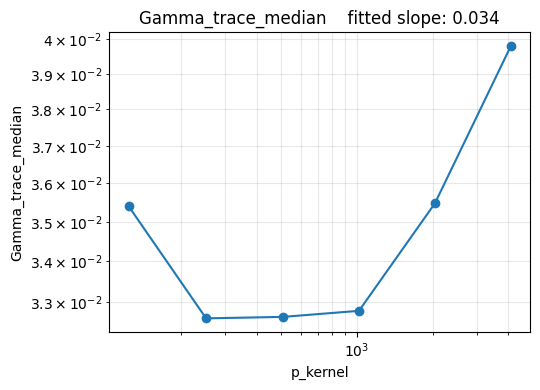

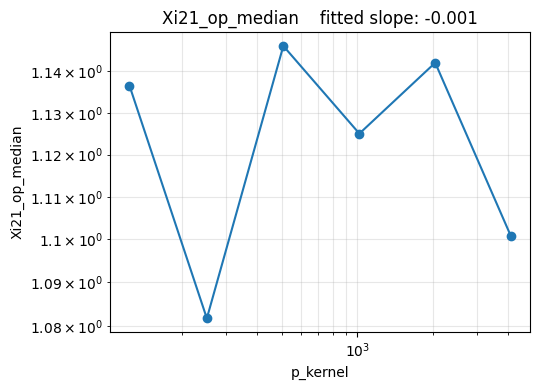

In [3]:
# 2. Fixed nout, increasing ntr:

raw_ntr, summary_ntr, slopes_ntr = run_schur_correction_report(
    sweep_col="ntr",
    d=2,
    nout=32,
    ntr_values=(128, 256, 512, 1024, 2048, 4096),
    trials=30,
    noise="gaussian",
    seed=8,
    ycols=("term_op_median", "Gamma_trace_median", "Xi21_op_median"),
    show_slopes=False,
)


# 3. Exact multinomial noise instead of Gaussian noise:
#
# raw_m, summary_m, slopes_m = run_schur_correction_report(
#     sweep_col="nout",
#     d=2,
#     nout_values=(8, 12, 16, 24, 32),
#     ntr_multiplier=100,
#     trials=10,
#     Nshots=5000,
#     noise="multinomial",
#     seed=9,
# )


In [ ]:
# 4. Schur-complement approximation check at fixed d and nout, increasing ntr.
#
# Empirical Schur term:
#   Xi11 - S12 S22^+ Xi21
# Limit-covariance approximation:
#   Xi11 - C12 C22^+ Xi21
# Xi11-only approximation:
#   Xi11

schur_complement_raw, schur_complement_summary = run_schur_complement_approx_experiment(
    d=2,
    nout=32,
    ntr_values=(128, 256, 512, 1024, 2048, 4096),
    trials=20,
    noise="gaussian",
    Nshots=1000,
    seed=20260609,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    relative_error_threshold=0.10,
    plot_specs=SCHUR_COMPLEMENT_APPROX_PLOTS,
)


d=2, nout=32, ntr=32, trials=20
d=2, nout=32, ntr=40, trials=20
d=2, nout=32, ntr=50, trials=20
d=2, nout=32, ntr=100, trials=20
d=2, nout=32, ntr=256, trials=20
d=2, nout=32, ntr=512, trials=20
d=2, nout=32, ntr=1024, trials=20
d=2, nout=32, ntr=2048, trials=20
d=2, nout=32, ntr=4096, trials=20


,ntr,p_kernel,q,empirical_schur_op_median,limit_approx_error_op_median,xi11_approx_error_op_median,limit_relative_error_median,xi11_relative_error_median,empirical_correction_over_xi11_median,limit_approx_ok_median,xi11_approx_ok_median,C22_lambda_min_median,S22_lambda_min_median
0,32,28,28,6.075530,5.804561,5.713563,1.001768,1.001594,8.823137,False,False,0.003739,0.000005
1,40,36,28,1.246140,1.089829,1.139742,0.923115,0.927057,1.757170,False,False,0.002552,0.000254
2,50,46,28,0.864912,0.713013,0.800389,0.788764,0.955727,1.182899,False,False,0.004229,0.000956
3,100,96,28,0.661748,0.402267,0.468564,0.630487,0.692484,0.710371,False,False,0.003599,0.002178
4,256,252,28,0.570620,0.187854,0.355236,0.335473,0.575432,0.569249,False,False,0.003770,0.003135
5,512,508,28,0.589442,0.127276,0.276565,0.247251,0.516822,0.524839,False,False,0.003361,0.003058
6,1024,1020,28,0.615392,0.090495,0.377058,0.135428,0.629710,0.524422,False,False,0.003186,0.002981
7,2048,2044,28,0.563401,0.062619,0.326260,0.130170,0.606145,0.611425,False,False,0.003360,0.003219
8,4096,4092,28,0.503092,0.051261,0.295504,0.088418,0.517420,0.468170,True,False,0.004343,0.004426


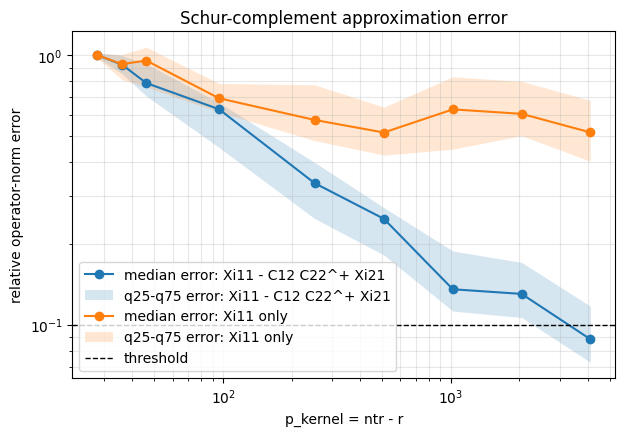

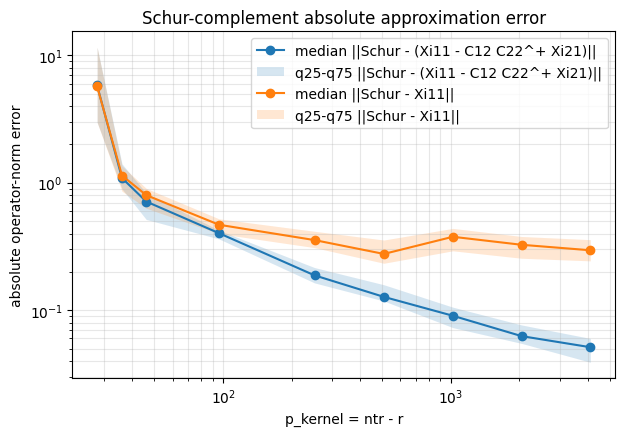

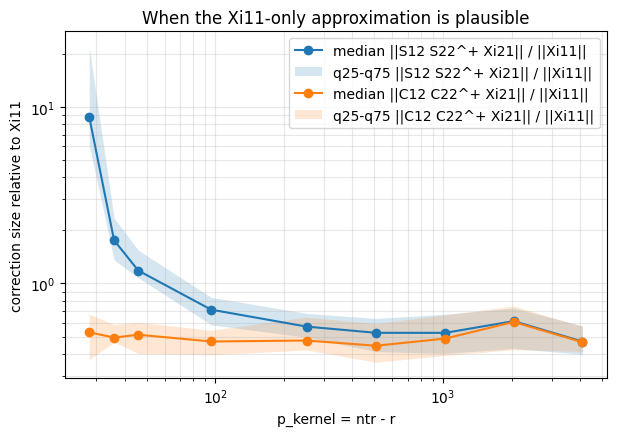

In [6]:
schur_complement_raw, schur_complement_summary = run_schur_complement_approx_experiment(
    d=2,
    nout=32,
    ntr_values=(32, 40, 50, 100, 256, 512, 1024, 2048, 4096),
    trials=20,
    noise="gaussian",
    Nshots=10000,
    seed=20260609,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    relative_error_threshold=0.10,
    plot_specs=SCHUR_COMPLEMENT_APPROX_PLOTS,
)


d=2, nout=32, ntr=32, trials=30
d=2, nout=32, ntr=40, trials=30
d=2, nout=32, ntr=50, trials=30
d=2, nout=32, ntr=100, trials=30
d=2, nout=32, ntr=256, trials=30
d=2, nout=32, ntr=512, trials=30
d=2, nout=32, ntr=1024, trials=30
d=2, nout=32, ntr=2048, trials=30
d=2, nout=32, ntr=4096, trials=30


,ntr,p_kernel,q,empirical_schur_op_median,limit_approx_error_op_median,xi11_approx_error_op_median,limit_relative_error_median,xi11_relative_error_median,empirical_correction_over_xi11_median,limit_approx_ok_median,xi11_approx_ok_median,C22_lambda_min_median,S22_lambda_min_median
0,32,28,28,4.394697,4.278482,4.378922,0.995074,0.990215,7.330272,False,False,0.002930,0.000009
1,40,36,28,1.187577,0.974460,1.062522,0.883720,0.922899,1.712160,False,False,0.003256,0.000285
2,50,46,28,1.013949,0.792887,0.924633,0.807639,0.887441,1.319346,False,False,0.004475,0.000975
3,100,96,28,0.606628,0.338174,0.381530,0.544467,0.655143,0.608246,False,False,0.003328,0.001821
4,256,252,28,0.579414,0.201417,0.376901,0.386543,0.610251,0.603364,False,False,0.003565,0.002976
5,512,508,28,0.534079,0.128126,0.302914,0.241630,0.591792,0.547204,False,False,0.003517,0.003163
6,1024,1020,28,0.553423,0.090961,0.310612,0.174217,0.617723,0.478494,False,False,0.003135,0.003010
7,2048,2044,28,0.562788,0.060219,0.273719,0.114563,0.483028,0.447937,False,False,0.004109,0.004139
8,4096,4092,28,0.594668,0.050976,0.325996,0.084713,0.534913,0.466604,True,False,0.003456,0.003441


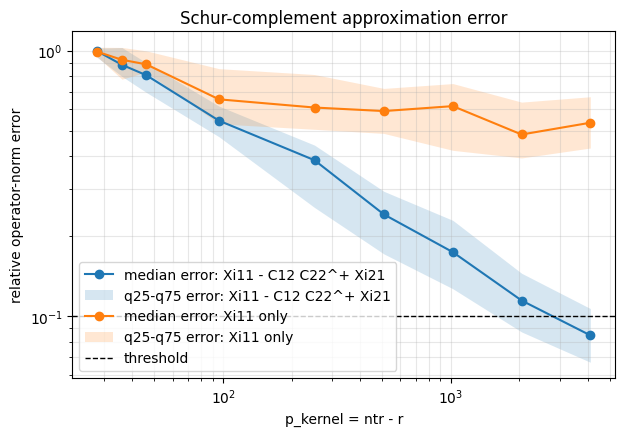

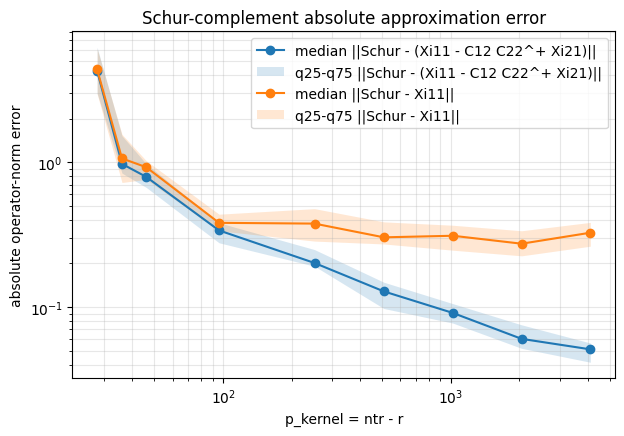

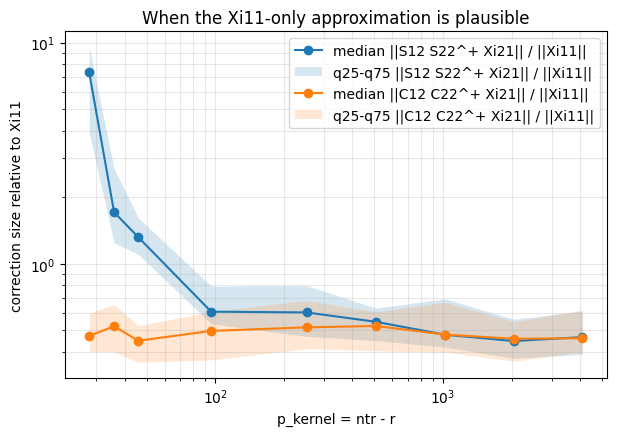

In [7]:
schur_complement_raw, schur_complement_summary = run_schur_complement_approx_experiment(
    d=2,
    nout=32,
    ntr_values=(32, 40, 50, 100, 256, 512, 1024, 2048, 4096),
    trials=30,
    noise="gaussian",
    Nshots=100,
    seed=20609,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    relative_error_threshold=0.10,
    plot_specs=SCHUR_COMPLEMENT_APPROX_PLOTS,
)


d=4, nout=64, ntr=32, trials=30
d=4, nout=64, ntr=40, trials=30
d=4, nout=64, ntr=50, trials=30
d=4, nout=64, ntr=100, trials=30
d=4, nout=64, ntr=256, trials=30
d=4, nout=64, ntr=512, trials=30
d=4, nout=64, ntr=1024, trials=30
d=4, nout=64, ntr=2048, trials=30
d=4, nout=64, ntr=4096, trials=30


/usr/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a


,ntr,p_kernel,q,empirical_schur_op_median,limit_approx_error_op_median,xi11_approx_error_op_median,limit_relative_error_median,xi11_relative_error_median,empirical_correction_over_xi11_median,limit_approx_ok_median,xi11_approx_ok_median,C22_lambda_min_median,S22_lambda_min_median
0,32,16,48,1.341622,0.938447,0.974240,0.740377,0.734846,0.924562,False,False,0.003639,-3.190605e-17
1,40,24,48,1.567106,1.355400,1.365823,0.815660,0.824093,1.309671,False,False,0.003560,-1.939668e-17
2,50,34,48,2.206776,2.136930,2.149160,0.935593,0.955821,2.030315,False,False,0.003276,-1.215353e-17
3,100,84,48,1.544108,1.319234,1.362201,0.841349,0.881176,1.373908,False,False,0.003721,7.066352e-04
4,256,240,48,1.098515,0.546575,0.656854,0.496661,0.602016,0.644452,False,False,0.003323,2.314943e-03
5,512,496,48,1.029718,0.360645,0.507919,0.342812,0.495957,0.516609,False,False,0.003943,3.322522e-03
6,1024,1008,48,1.008082,0.242688,0.424231,0.248820,0.424084,0.397373,False,False,0.003310,2.991791e-03
7,2048,2032,48,0.992595,0.165329,0.419742,0.166499,0.422193,0.410588,False,False,0.003318,3.097610e-03
8,4096,4080,48,0.966829,0.115321,0.391440,0.116832,0.402821,0.383932,False,False,0.003685,3.631004e-03


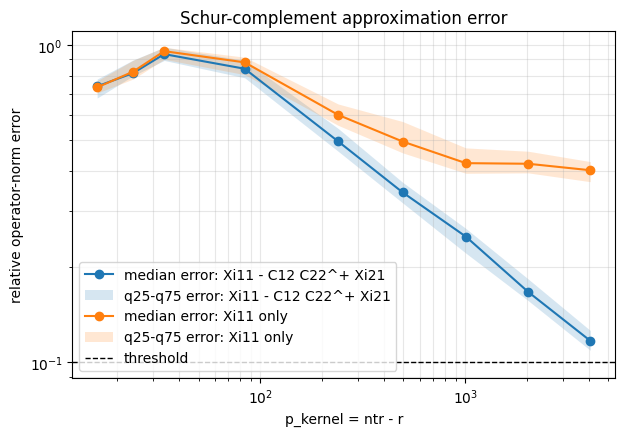

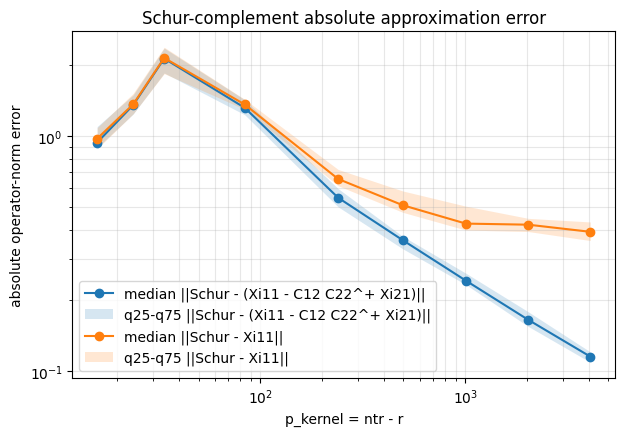

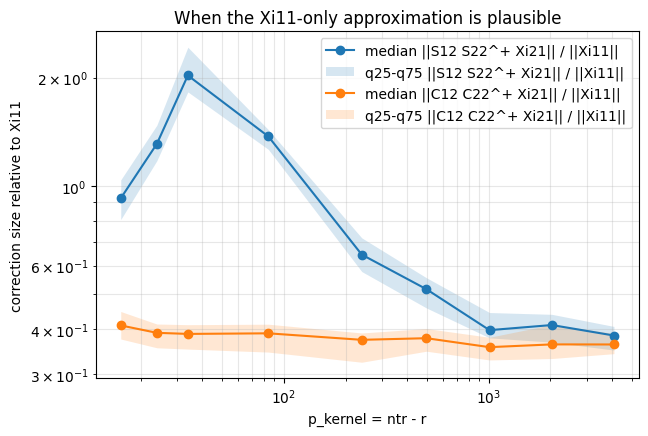

In [10]:
schur_complement_raw, schur_complement_summary = run_schur_complement_approx_experiment(
    d=4,
    nout=64,
    ntr_values=(32, 40, 50, 100, 256, 512, 1024, 2048, 4096),
    trials=30,
    noise="gaussian",
    Nshots=100,
    seed=20609,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    relative_error_threshold=0.10,
    plot_specs=SCHUR_COMPLEMENT_APPROX_PLOTS,
)


d=4, nout=64, ntr=32, trials=30
d=4, nout=64, ntr=40, trials=30
d=4, nout=64, ntr=50, trials=30
d=4, nout=64, ntr=100, trials=30
d=4, nout=64, ntr=256, trials=30
d=4, nout=64, ntr=512, trials=30
d=4, nout=64, ntr=1024, trials=30
d=4, nout=64, ntr=2048, trials=30
d=4, nout=64, ntr=4096, trials=30


/usr/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a


,ntr,p_kernel,q,empirical_schur_op_median,limit_approx_error_op_median,xi11_approx_error_op_median,limit_relative_error_median,xi11_relative_error_median,empirical_correction_over_xi11_median,limit_approx_ok_median,xi11_approx_ok_median,C22_lambda_min_median,S22_lambda_min_median
0,32,16,48,1.326263,0.969626,0.989384,0.746043,0.722305,0.926411,False,False,0.003639,-2.838380e-17
1,40,24,48,1.521119,1.292265,1.283667,0.846178,0.840953,1.254330,False,False,0.003560,-2.040826e-17
2,50,34,48,2.282941,2.244190,2.187881,0.940419,0.950192,2.107647,False,False,0.003276,-1.307159e-17
3,100,84,48,1.533011,1.316479,1.331292,0.833670,0.853851,1.277829,False,False,0.003721,8.224014e-04
4,256,240,48,1.107804,0.546429,0.642112,0.492897,0.596176,0.624933,False,False,0.003323,2.266900e-03
5,512,496,48,1.027114,0.342151,0.502579,0.344777,0.490473,0.480155,False,False,0.003943,3.253350e-03
6,1024,1008,48,1.013689,0.243509,0.438190,0.241272,0.448498,0.430597,False,False,0.003310,2.947923e-03
7,2048,2032,48,0.942463,0.171116,0.418485,0.179907,0.441050,0.411813,False,False,0.003318,3.187657e-03
8,4096,4080,48,0.974086,0.112995,0.403174,0.114299,0.415175,0.387291,False,False,0.003685,3.633115e-03


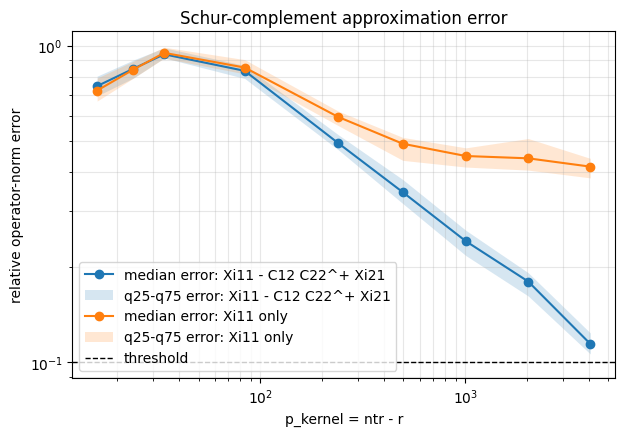

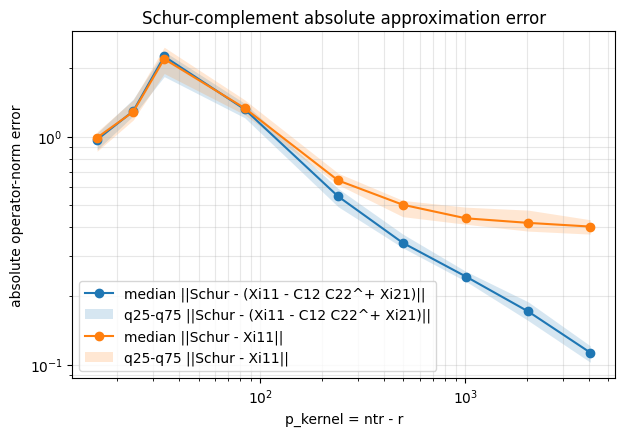

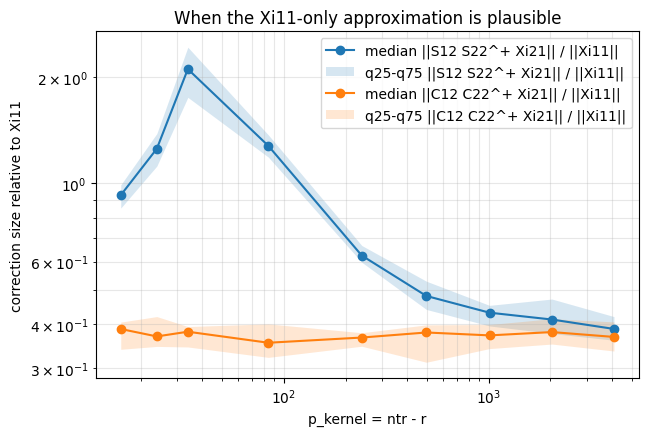

In [4]:
schur_complement_raw, schur_complement_summary = run_schur_complement_approx_experiment(
    d=4,
    nout=64,
    ntr_values=(32, 40, 50, 100, 256, 512, 1024, 2048, 4096),
    trials=30,
    noise="centered_gaussian",
    Nshots=100,
    seed=20609,
    rcond=1e-12,
    ridge=0.0,
    rank=None,
    relative_error_threshold=0.10,
    plot_specs=SCHUR_COMPLEMENT_APPROX_PLOTS,
)


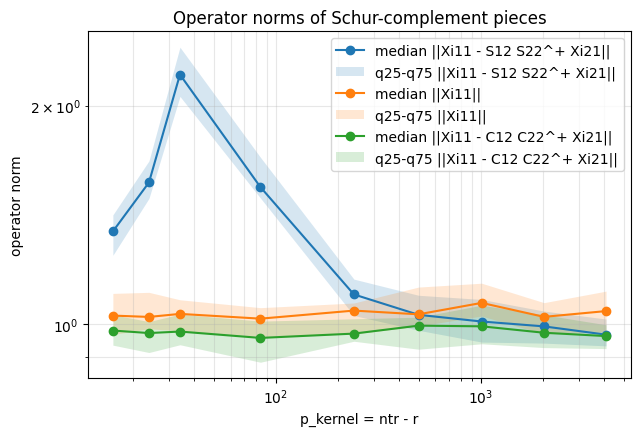

In [12]:
# 5. Operator norms of Schur-complement pieces.
#
# Run this after run_schur_complement_approx_experiment(...) has produced
# schur_complement_summary. It uses the existing q25/median/q75 summary columns.

plot_summary_series(
    schur_complement_summary,
    x_col="p_kernel",
    plots=SCHUR_COMPLEMENT_NORM_PLOTS,
)


# Focus on corrections due to the $C_{22}^{-1}C_{21}$

Study how much results change if we approximate $\tilde U U_1^T = I - U_2 C_{22}^{-1} C_{21}U_1^T \simeq I$.

Here $\tilde U \equiv U_1 - U_2 C_{22}^{-1} C_{21}$,
$C_{ab}=\frac1{d^2-n_{\rm tr}}\sum_i(\Pi_2)_{ii}U_a^T\boldsymbol{\Sigma}_iU_b$,
$\Pi_2 = I - \Pi_1 = V_2 V_2^T$, $\Pi_1=V_1V_1^T$,
$\Pi_{\bar 1}=\Pi_{\mathrm{im}(P)}=U_1 U_1^T$,
$\Pi_{\bar 2} = I-\Pi_{\bar 1}=U_2 U_2^T$,
$\Xi_{ab}\equiv U_a^T\Xi V_b$,
$P_{ab}\equiv U_a^T P V_b$,
$\Sigma_i = \mathrm{diag}(p_i) - p_i p_i^T$,
$p_i = \langle\mu,\rho_i\rangle$.

The main places this approximation enters is the leading corrections for training bias and variance, which equal
$$\providecommand{\bsw}{\boldsymbol{w}}
    \mathrm{bias}_{\rm tr}^2(N) =
    \frac{1}{N^2}
    \left[
    \sum_{i=1}^{n_{\rm tr}}
    \mathrm{Cov}\left(
    \tilde UU_1^T\bsw_\mathcal O,
    \tilde UU_1^T\langle\mu,\tilde\sigma\rangle
    \right)
    \right]^2
    +
    O\left(\frac{1}{N^{5/2}}\right)
    + O\left(\frac{1}{N^{2} n_{\rm tr}}\right),
    \\
    \mathrm{Var}_{\rm tr}(N) =
    \frac{1}{N}
    \sum_{i=1}^{n_{\rm tr}}
    \langle\tilde\rho_i,\sigma\rangle^2
    \mathrm{Var}[\tilde{\bsw}_\mathcal O\mid\rho_i]
    + O\left(\frac{1}{N^2 n_{\rm tr}}\right),
$$
where
$\tilde{\bsw}\equiv \tilde U U_1^T\bsw$,
$\bsw\equiv\bsw_{\mathcal O} \equiv \langle\tilde\mu,\mathcal O\rangle$,
$\bsw_a \equiv \langle\tilde\mu_a,\mathcal O\rangle = \langle F_\mu^{-1}(\mu_a),\mathcal O\rangle$,
$\langle\tilde\rho,\sigma\rangle_i=\langle\tilde\rho_i,\sigma\rangle=\langle F_\rho^{-1}(\rho_i),\sigma\rangle$,
$F_\mu(A)\equiv \sum_{a=1}^{n_{\rm out}} \mu_a \mathrm{Tr}(\mu_a A)$,
$F_\rho(A)\equiv \sum_{a=1}^{n_{\rm tr}} \rho_i \mathrm{Tr}(\rho_i A)$,
$P \equiv \langle\mu,\rho\rangle$,
$P^+ =\langle\tilde\rho,\tilde\mu\rangle$,
$\langle\mu,\tilde\sigma\rangle_a=\langle\mu_a,\tilde\sigma\rangle=\langle \mu_a,F_\rho^{-1}(\sigma)\rangle$

We want to study
- how the operator norm of $C_{22}^{-1} C_{21}$ and $U_2 C_{22}^{-1} C_{21} U_1^T$ scales with $N,n_{\rm tr}, n_{\rm out}, d$. Always remaining in the regimes $n_{\rm tr}\ge n_{\rm out}\ge d^2$.
- the scaling of the training squared bias and variance using the leading terms in the above equations, and how much results change with and without the approximation $\tilde UU_1^T\simeq I$.
- how well the leading approximation terms above reproduce the actual numerical results. This can be done eg computing the actual MSE (always at infinite test statistics, but with finite training statistics $N$), and comparing it with the sum of the leading terms of squared bias and variance given above.

In all plots show both mean and median, quantiles (leaving it easy to change these settings here in the notebook in the function call), use log log plots to make scalings easier to parse.

## Double checking that the MSE is doing what it should

## Plots for MSE and leading terms scalings

### MUB POVM and MUB states

with fixed test and obs

Elapsed time: 82.06s
Saved tilde-U report data to data/mub_mubstates_vsN.zip


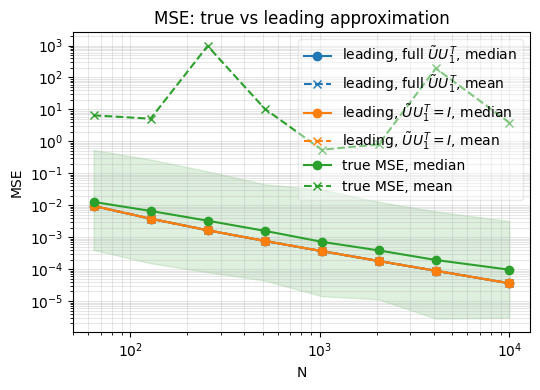

In [3]:
target_obs = np.array([[1.0, 0.0], [0.0, 0.0]])  # |0><0| for d=2
test_state = np.array([[1.0, 0.0], [0.0, 0.0]])
tilde_u_training_spec = QELMTrainingSpec(
    data=QELMDataSpec(d=2, povm=mub_povm, train_states=mub_povm * 3),
    target=QELMTargetRequest(observable=target_obs),
    test=QELMTestRequest(state=test_state),
    noise=QELMNoiseSpec(noise="multinomial", actual_noise_trials=1),
)
tilde_u_study = TildeUTrainingApproxStudySpec(
    base=tilde_u_training_spec,
    sweep_col="N",
    sweep_values=(64, 128, 256, 512, 1024, 2048, 4096, 10**4),
    repetitions=1000,
    quantiles=(0.10, 0.25, 0.75, 0.90),
    quantile_band=(0.1, 0.9),
    show_summary=False, show_slopes=False, plots='mse',
    output_file='data/mub_mubstates_vsN.zip'
)

tilde_u_raw_ntr, tilde_u_summary_ntr, tilde_u_slopes_ntr = run_tilde_u_training_approx_report(tilde_u_study)


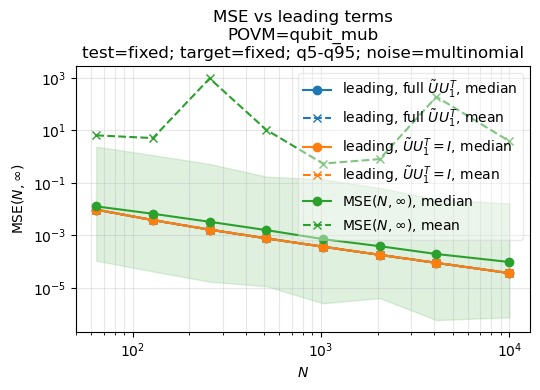

In [8]:
plot_saved_training_data("data/mub_mubstates_vsN.zip", plots="mse", quantile_band=(0.05, 0.95));

### MUB POVM, random states

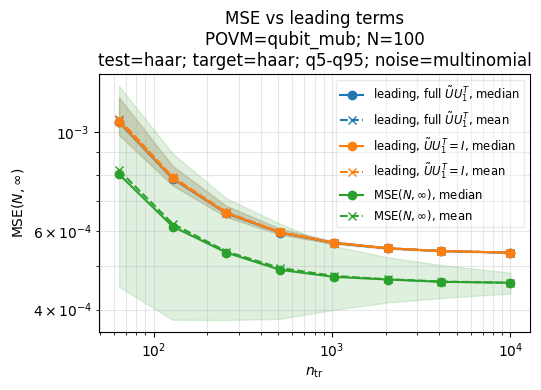

In [ ]:
plot_saved_traindata("data/mub_haarstates_N100_vsntr_extended.zip", plots="mse", quantile_band=(0.05, 0.95));

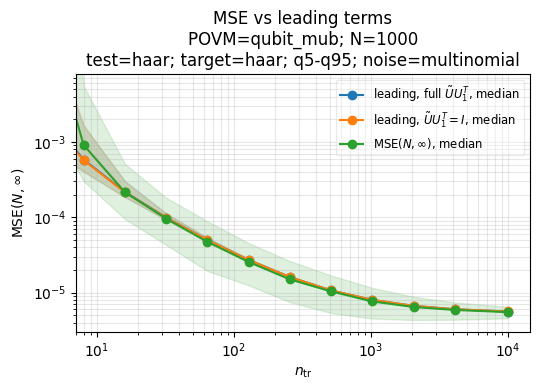

In [ ]:
plot_saved_traindata("data/mub_haarstates_N1000_vsntr_extended_1.zip",
                         plots="mse", quantile_band=(0.05, 0.95), show_mean=False,
                         xlim=(7, None));

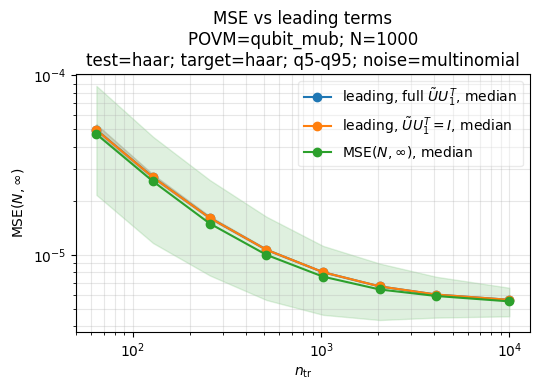

In [ ]:
plot_saved_traindata("data/mub_haarstates_N1000_vsntr_extended.zip",
                         plots="mse", quantile_band=(0.05, 0.95), show_mean=False);

### random rank-1 POVM

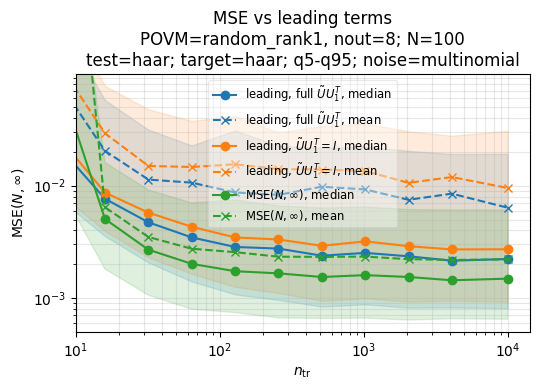

In [ ]:
plot_saved_traindata("data/rndnout8_haarstates_N100_vsntr.zip",
                         plots="mse", quantile_band=(0.05, 0.95), xlim=(10, None),
                         legend_outside=False);

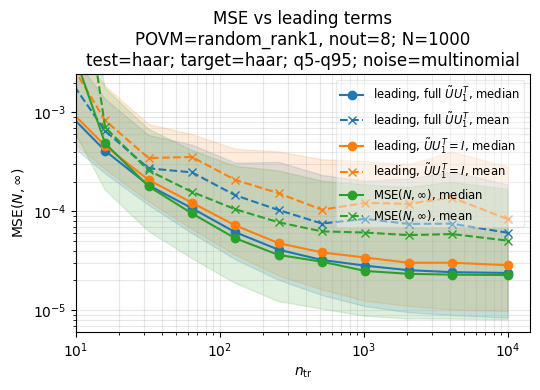

In [ ]:
plot_saved_traindata("data/rndnout8_haarstates_N1000_vsntr.zip",
                         plots="mse", quantile_band=(0.05, 0.95), xlim=(10, None));

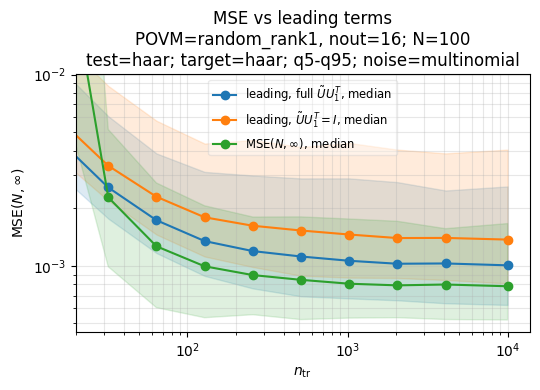

In [ ]:
plot_saved_traindata("data/rndnout16_haarstates_N100_vsntr.zip",
                         plots="mse", quantile_band=(0.05, 0.95), xlim=(20, None),
                         show_mean=False);

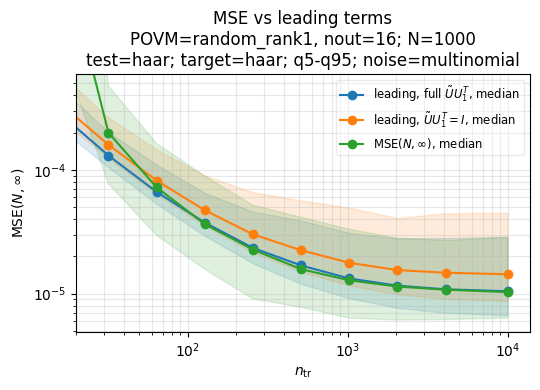

In [ ]:
plot_saved_traindata("data/rndnout16_haarstates_N1000_vsntr_ext.zip",
                         plots="mse", quantile_band=(0.05, 0.95), xlim=(20, None),
                         show_mean=False);

In [20]:
from scripts.summarize_data_folder import tested_values_table, read_report_zip

metadata = read_report_zip("data/rndpovm_haarstates_avgtesttarget_grid/rndpovm_haarstates_avgtesttarget_grid_d2_nout16.zip")[1]
# plot the actual_mse value of the dataframe df, as a function of ntr, for the various values of N
len(metadata['assigned_configs']), len(metadata['completed_configs'])


(120, 36)

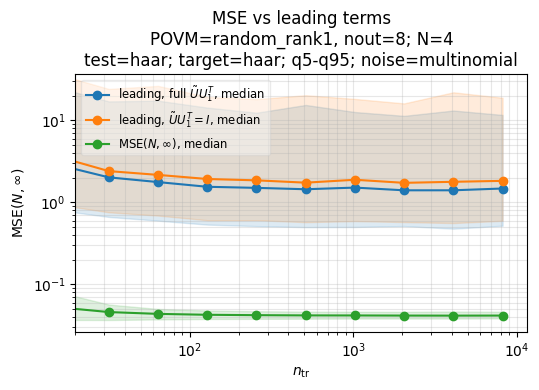

In [ ]:
# from qelm.training_reports import load_traindata, summarize_dataraw
# df = load_traindata("data/rndpovm_haarstates_avgtesttarget_grid/_d2_nout8_N4_vsntr.zip").expanded_df()
# summarize_dataraw(df)
path = "data/rndpovm_haarstates_avgtesttarget_grid/_d2_nout8_N4_vsntr.zip"
plot_saved_traindata(path,
                         plots="mse", quantile_band=(0.05, 0.95), xlim=(20, None),
                         show_mean=False);

# Reading grid files

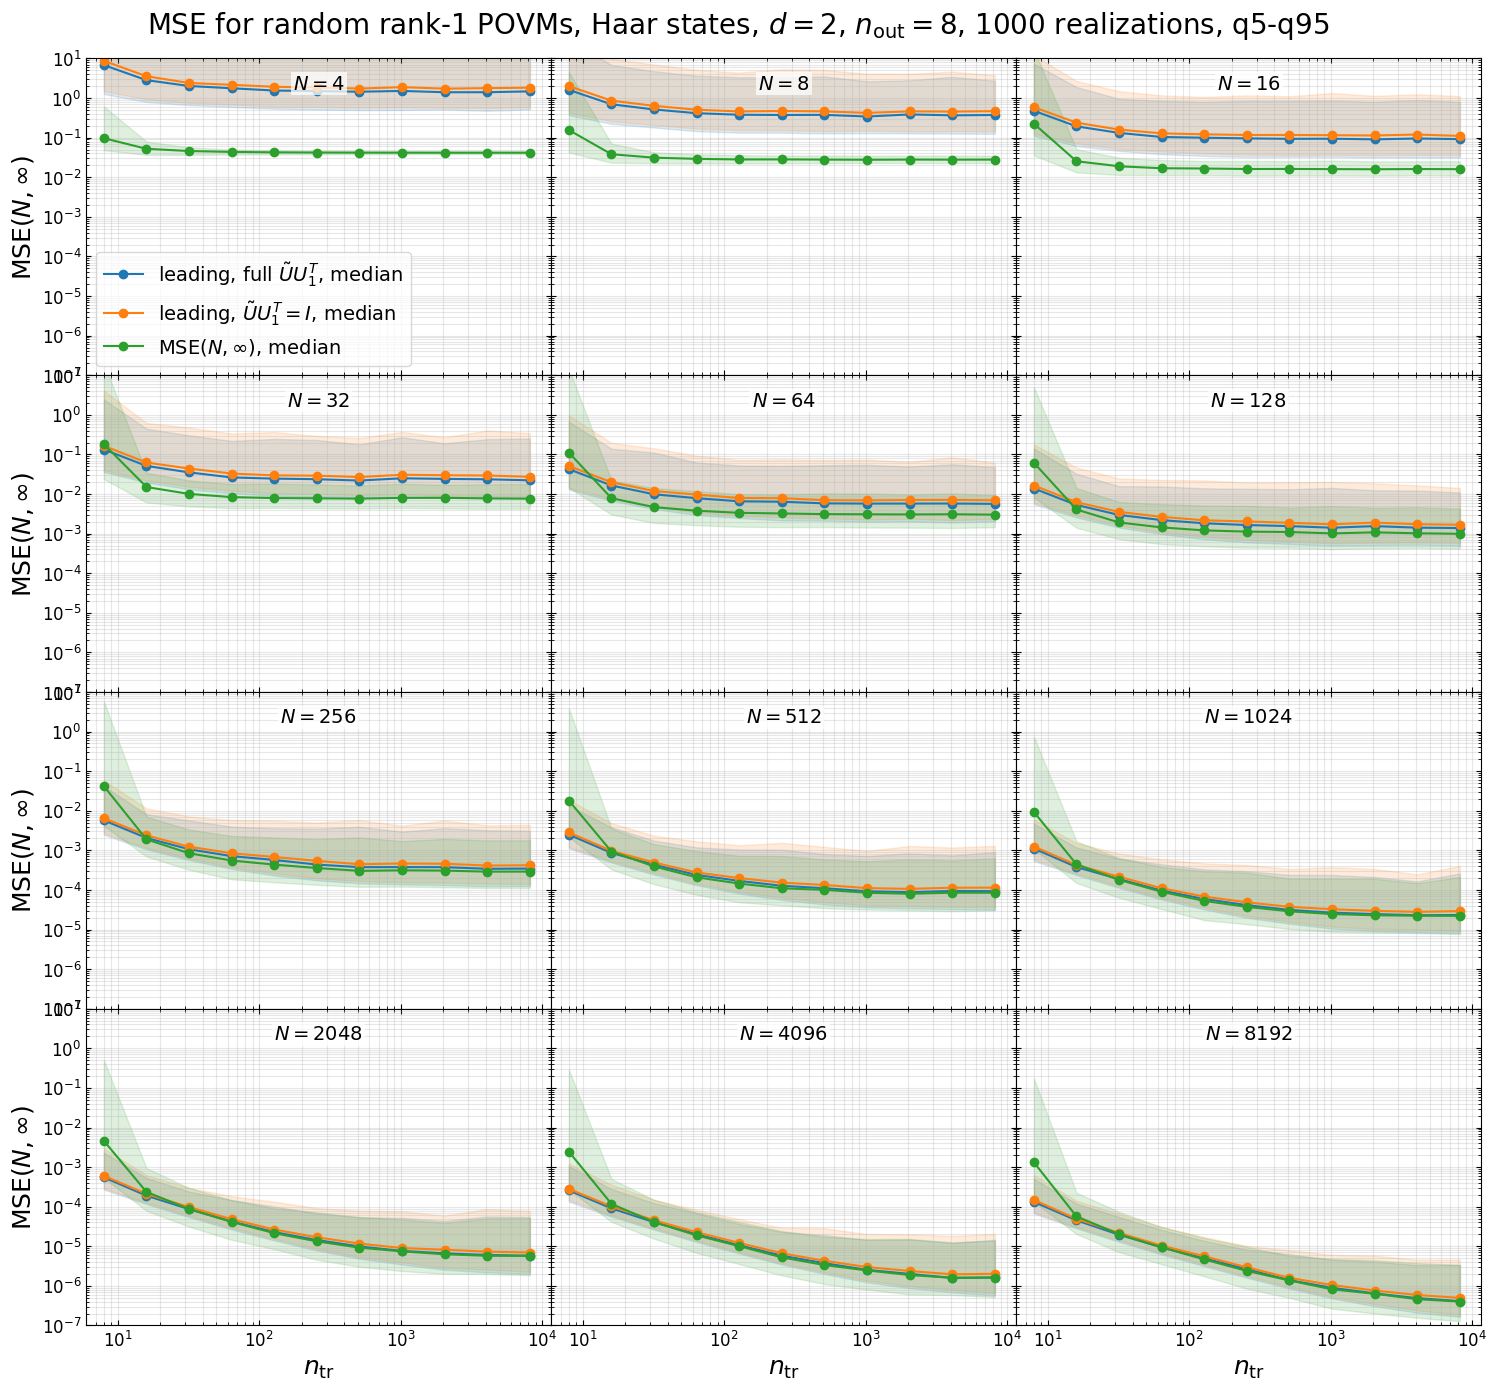

In [ ]:
fig, axes = plot_mse_grid_over_N(
    folder="data/rndpovm_haarstates_avgtesttarget_grid",
    d=2, nout=8,
    n_min=2, n_max=13,
    xlim=(6, None), ylim=(1e-7, 10),
)
plt.show()

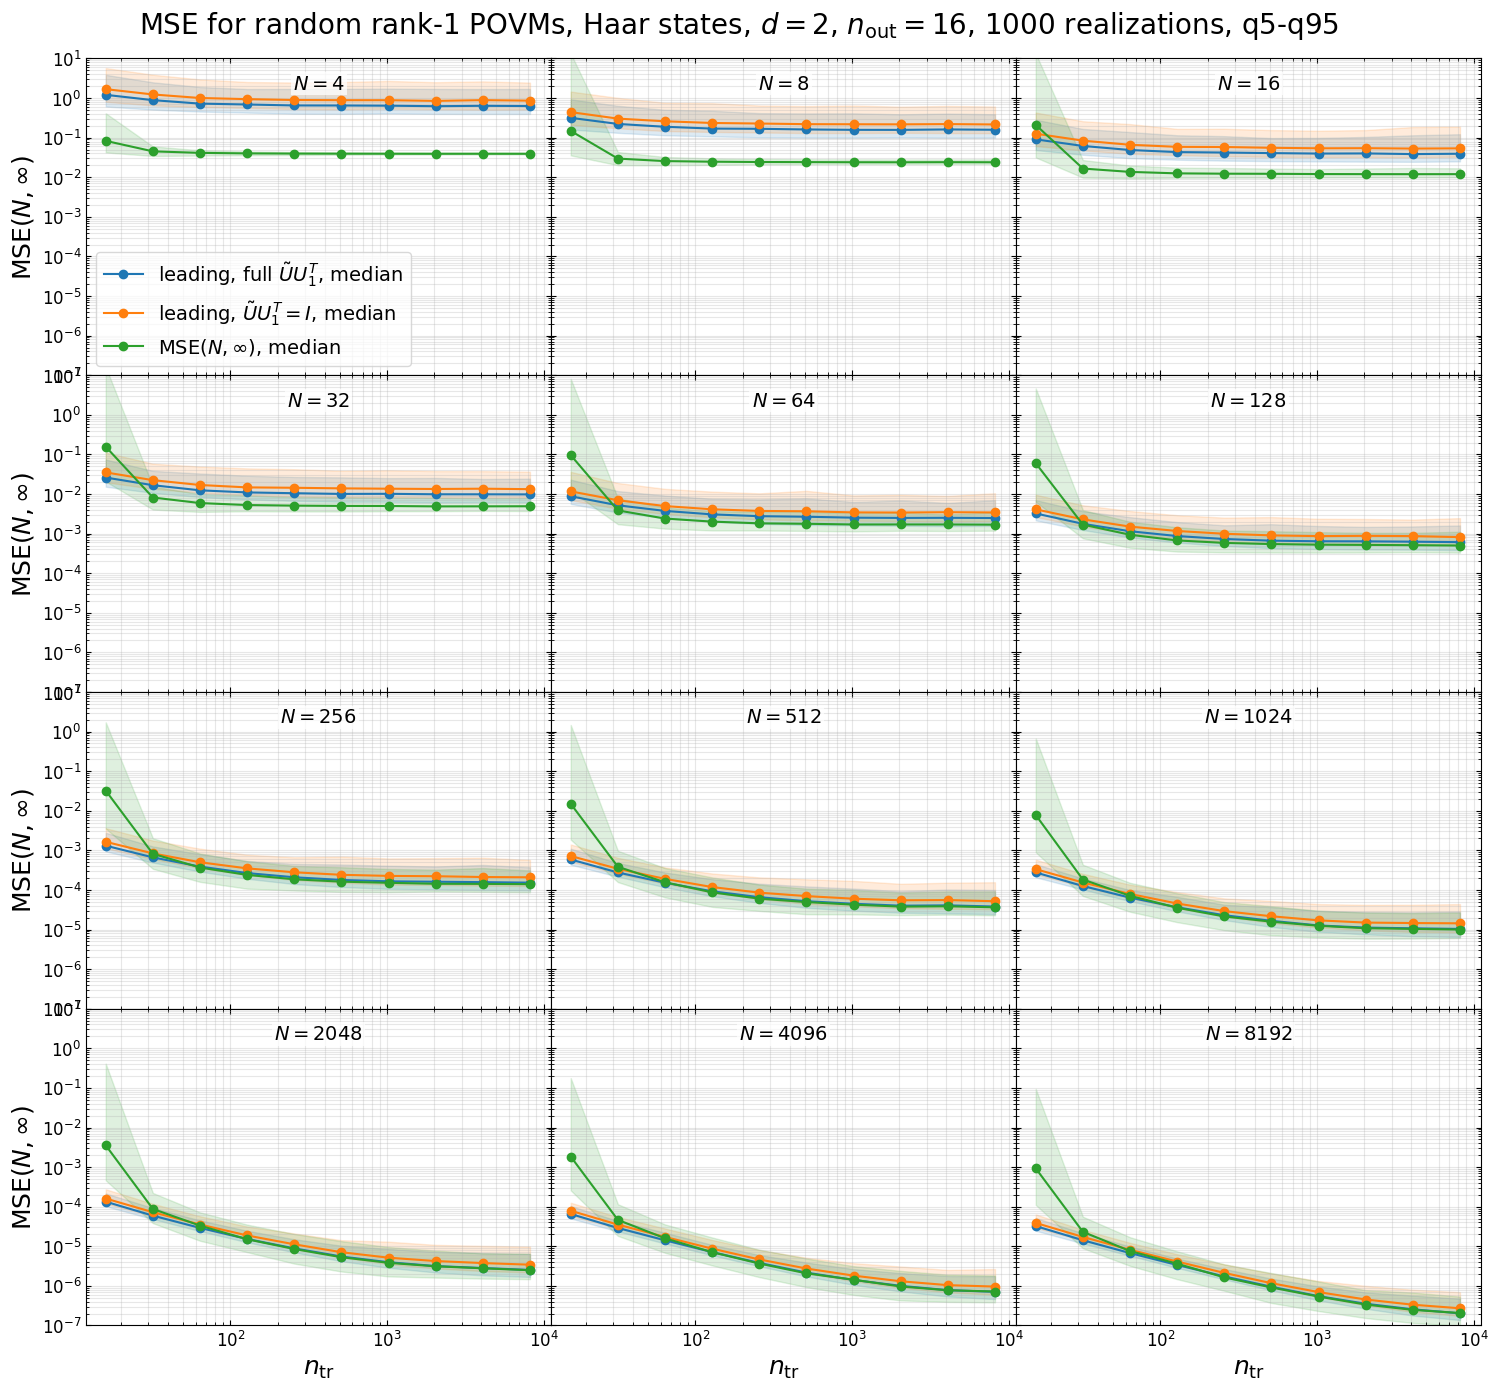

In [ ]:
fig, axes = plot_mse_grid_over_N(
    folder="data/rndpovm_haarstates_avgtesttarget_grid",
    d=2, nout=16,
    n_min=2, n_max=13,
    xlim=(12, None), ylim=(1e-7, 10),
)
plt.show()